# Homework 2

In [20]:
import numpy as np               
import matplotlib.pyplot as plt  
from time import time
import cv2                       

plt.rcParams['figure.figsize'] = (10.0, 8.0) # set default size of plots
plt.rcParams['image.interpolation'] = 'nearest'
plt.rcParams['image.cmap'] = 'gray'

%matplotlib inline

---
# Часть 1: Свертки

## Оценка

* 40% баллов, если есть хоть какая-то реализация свёртки
* 10% за реализацию ConvFilterNested
* 20% за реализацию ConcFilterFast
* 30%, если второе быстрее или первое и второе оба работают быстро (бывает и такое)
* Дополнительные 50% за успешную реализацию задания со звёздочкой

## Реализация

В этом разделе вы реализуете две версии свертки:
- `ConvFilterNested`
- `ConcFilterFast`

Сначала запустите нижеуказанную кодовую ячейку, чтобы загрузить изображение для работы.

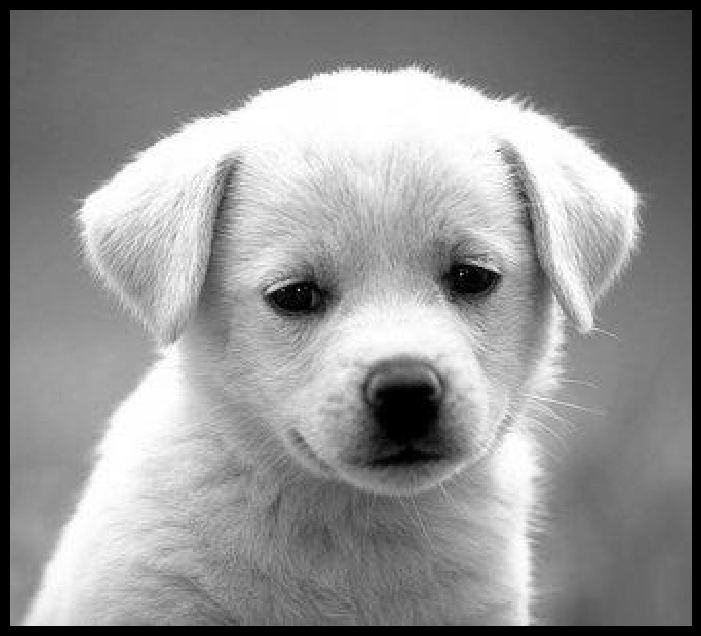

In [21]:
# Open image as grayscale
img = cv2.imread('img/dog.jpg', 0)

# Show image
plt.imshow(img)
plt.axis('off')
plt.show()

Теперь реализуем функцию **`ConvFilterNested`** в **`filters.py`**. Это наивная реализация convolution, использующая 4 вложенных for-loops. В качестве входа и выхода она берет изображение $f$ и ядро $h$, которое имеет ту же форму, что и входное изображение. Запуск этой реализации должен занять несколько секунд.

*- Подсказка: Возможно, будет проще реализовать $(h*f)$*.

Сначала мы протестируем вашу функцию `ConvFilterNested` на простом входе.

In [22]:
from filters import ConvFilterNested, ConvFilterFast, ConvFilterFaster, ConvFilterBest, ZeroPad

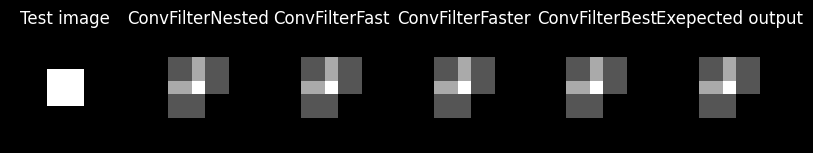

In [ ]:
# Simple convolution kernel.
kernel = np.array(
[
    [1,0,1],
    [0,0,0],
    [1,0,0]
])

# Create a test image: a white square in the middle
test_img = np.zeros((9, 9))
test_img[3:6, 3:6] = 1

# Build the expected output
expected_output = np.zeros((9, 9))
expected_output[2:7, 2:7] = 1
expected_output[5:, 5:] = 0
expected_output[4, 2:5] = 2
expected_output[2:5, 4] = 2
expected_output[4, 4] = 3

# Plot the test image
plt.subplot(1, 6, 1)
plt.imshow(test_img)
plt.title('Test image')
plt.axis('off')

# Plot your convolved image
plt.subplot(1, 6, 2)
plt.imshow(ConvFilterNested(test_img, kernel))
plt.title('ConvFilterNested')
plt.axis('off')

# Plot your convolved image
plt.subplot(1, 6, 3)
plt.imshow(ConvFilterFast(test_img, kernel))
plt.title('ConvFilterFast')
plt.axis('off')

# Plot your convolved image
plt.subplot(1, 6, 4)
plt.imshow(ConvFilterFaster(test_img, kernel))
plt.title('ConvFilterFaster')
plt.axis('off')

# Plot your convolved image
plt.subplot(1, 6, 5)
plt.imshow(ConvFilterBest(test_img, kernel))
plt.title('ConvFilterBest')
plt.axis('off')

# Plot the exepected
plt.subplot(1, 6, 6)
plt.imshow(expected_output)
plt.title('Exepected')
plt.axis('off')
plt.show()

Теперь давайте протестируем вашу функцию `ConvFilterNested` на реальном изображении.

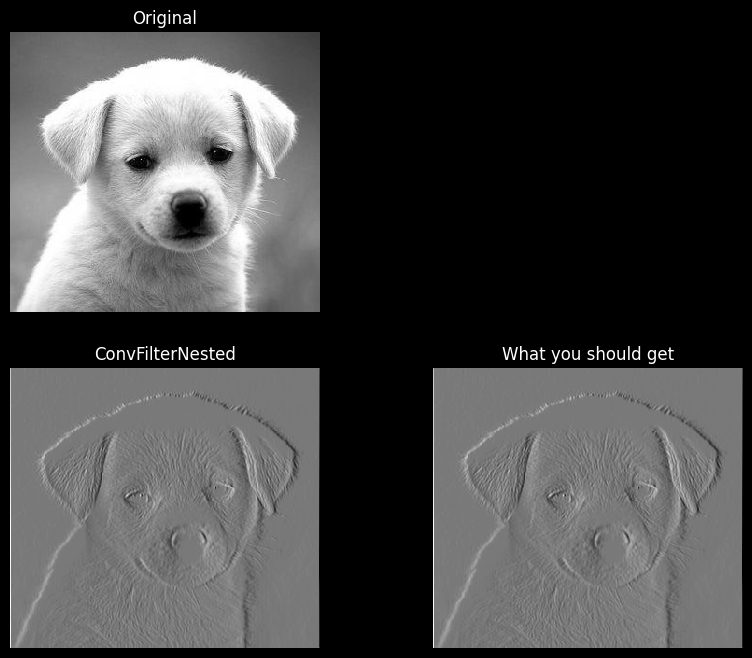

In [24]:
# Simple convolution kernel.
# Feel free to change the kernel to see different outputs.
kernel = np.array(
[
    [1,0,-1],
    [2,0,-2],
    [1,0,-1]
])

out_faster = ConvFilterNested(img, kernel)
# out = cv2.filter2D(img, -1, kernel)

# Plot original image
plt.subplot(221)
plt.imshow(img)
plt.title('Original')
plt.axis('off')

# Plot your convolved image
plt.subplot(223)
plt.imshow(out_faster)
plt.title('ConvFilterNested')
plt.axis('off')

# Plot what you should get
solution_img = cv2.imread('img/convoluted_dog.jpg', 0)
plt.subplot(224)
plt.imshow(solution_img)
plt.title('What you should get')
plt.axis('off')

plt.show()

Реализуем более эффективный вариант свертки с использованием операций с массивами в numpy. Как показано в лекции, свертку можно рассматривать как скользящее окно, которое вычисляет сумму значений пикселей, взвешенных перевернутым ядром.

Более быстрая версия: 
* будет иметь нулевое изображение
* перевернёт ядро по горизонтали и вертикали
* вычислит взвешенную сумму окрестностей в каждом пикселе.

Во-первых, реализовать функцию **`zero_pad`** в **`filters.py`**.

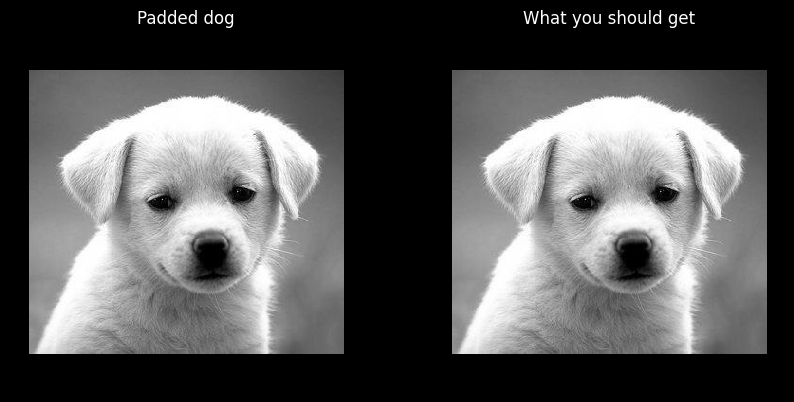

In [25]:
pad_width = 20 # width of the padding on the left and right
pad_height = 40 # height of the padding on the top and bottom

padded_img = ZeroPad(img, pad_height, pad_width)

# Plot your padded dog
plt.subplot(121)
plt.imshow(padded_img)
plt.title('Padded dog')
plt.axis('off')

# Plot what you should get
solution_img = cv2.imread('img/padded_dog.jpg', 0)
plt.subplot(122)
plt.imshow(solution_img)
plt.title('What you should get')
plt.axis('off')

plt.show()

Далее, выполните функцию **`ConcFilterFast`** в **`filters.py`** с помощью `zero_pad`. Запустите код ниже, чтобы сравнить результаты по двум реализациям. `ConcFilterFast` должна работать значительно быстрее, чем `ConvFilterNested`.  
В зависимости от вашей реализации и компьютера, `ConvFilterNested` должен занять несколько секунд и `ConcFilterFast` должен работать примерно в 5 раз быстрее.

ConcFilterNested: took 0.666521 seconds.
ConcFilterFast: took 0.633955 seconds.



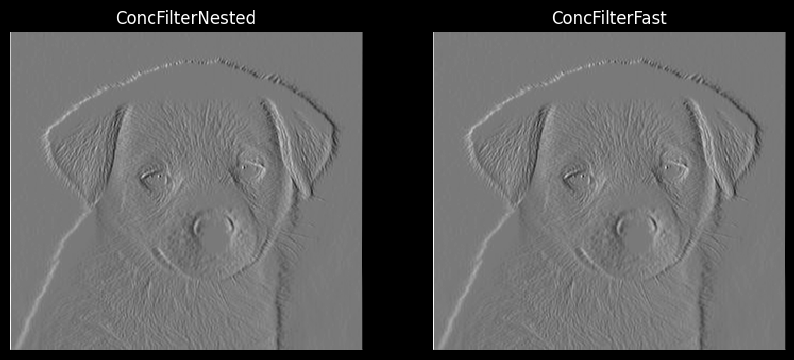

In [26]:
t0 = time()
out_fast = ConvFilterFast(img, kernel)
t1 = time()
out_nested = ConvFilterNested(img, kernel)
t2 = time()

# Compare the running time of the two implementations
print("ConcFilterNested: took %f seconds." % (t2 - t1))
print("ConcFilterFast: took %f seconds." % (t1 - t0))

# Plot ConcFilterNested output
plt.subplot(1, 2, 1)
plt.imshow(out_nested)
plt.title('ConcFilterNested')
plt.axis('off')

# Plot ConcFilterFast output
plt.subplot(1, 2, 2)
plt.imshow(out_fast)
plt.title('ConcFilterFast')
plt.axis('off')

print()

### Задание со звездочкой

Разработайте более быструю версию свертки и реализуйте **`ConcFilterFaster`** в **`filters.py`**. Вы заработаете дополнительный балл в том случае, если `ConcFilterFaster` будет работать быстрее (с достаточным запасом), чем `ConcFilterFast` **и** выдаст тот же результат.

ConcFilterFast: took 0.630581 seconds.
ConcFilterFaster: took 0.016486 seconds.
ConvFilterBest: took 0.083313 seconds.



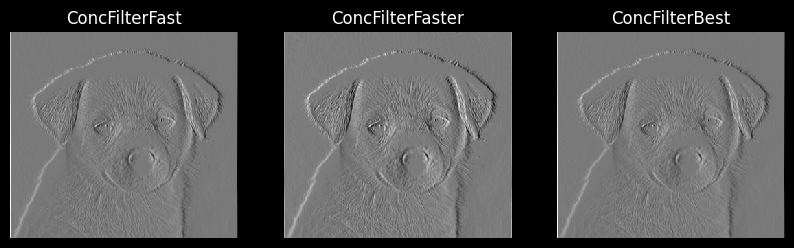

In [27]:
t0 = time()
out_fast = ConvFilterFast(img, kernel)
t1 = time()
out_faster = ConvFilterFaster(img, kernel)
t2 = time()
out_best = ConvFilterBest(img, kernel)
t3 = time()

# Compare the running time of the two implementations
print("ConcFilterFast: took %f seconds." % (t1 - t0))
print("ConcFilterFaster: took %f seconds." % (t2 - t1))
print("ConvFilterBest: took %f seconds." % (t3 - t2))

plt.subplot(1, 3, 1)
plt.imshow(out_fast)
plt.title('ConcFilterFast')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(out_faster)
plt.title('ConcFilterFaster')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(out_best)
plt.title('ConcFilterBest')
plt.axis('off')

print()

---
# Часть 2: Кросс-корреляция

Кросс-корреляция двух 2D сигналов $f$ и $g$ определяется следующим образом:
$$(f\star{g})[m,n]=\sum_{i=-\infty}^\infty\sum_{j=-\infty}^\infty f[i,j]\cdot g[m-i,n-j]$$

## Проверка шаблона с помощью кросс-корреляцией 

Предположим, что ты продавщица в продуктовом магазине. Одна из ваших обязанностей - периодически проверять полки и складировать их всякий раз, когда есть распроданные товары. Вы устали от этой кропотливой работы и решили построить систему компьютерного зрения, которая отслеживает предметы на полке.

К счастью, в CS131 вы узнали, что для сопоставления шаблонов можно использовать кросс-корреляцию: шаблон $g$ умножается на регионы с большим изображением $f$, чтобы измерить, насколько каждый регион похож на шаблон.

Шаблон товара (`template.jpg`) и изображение полки (`shelf.jpg`) предоставляются. Мы будем использовать кросс-корреляцию, чтобы найти товар на полке.

Реализуйте функцию **`cross_correlation`** в **`filters.py`** и запустите код ниже.

*- Подсказка: Вы можете использовать функцию `ConcFilterFast`, которую вы реализовали в предыдущем вопросе.

## Оценка

* 40% баллов, если нулевая кросс-корреляция находит коробку
* 10% баллов, если работает threshold
* 50% баллов, если работает нормализованная кросс-корреляция

In [28]:
# Load template and image in grayscale
img = cv2.imread('img/shelf.jpg')
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img_grey = cv2.imread('img/shelf.jpg', 0)

temp = cv2.imread('img/template.jpg')
temp = cv2.cvtColor(temp, cv2.COLOR_BGR2RGB)
temp_grey = cv2.imread('img/template.jpg', 0)

In [29]:
from filters import CrossCorrelation, ConvLevel

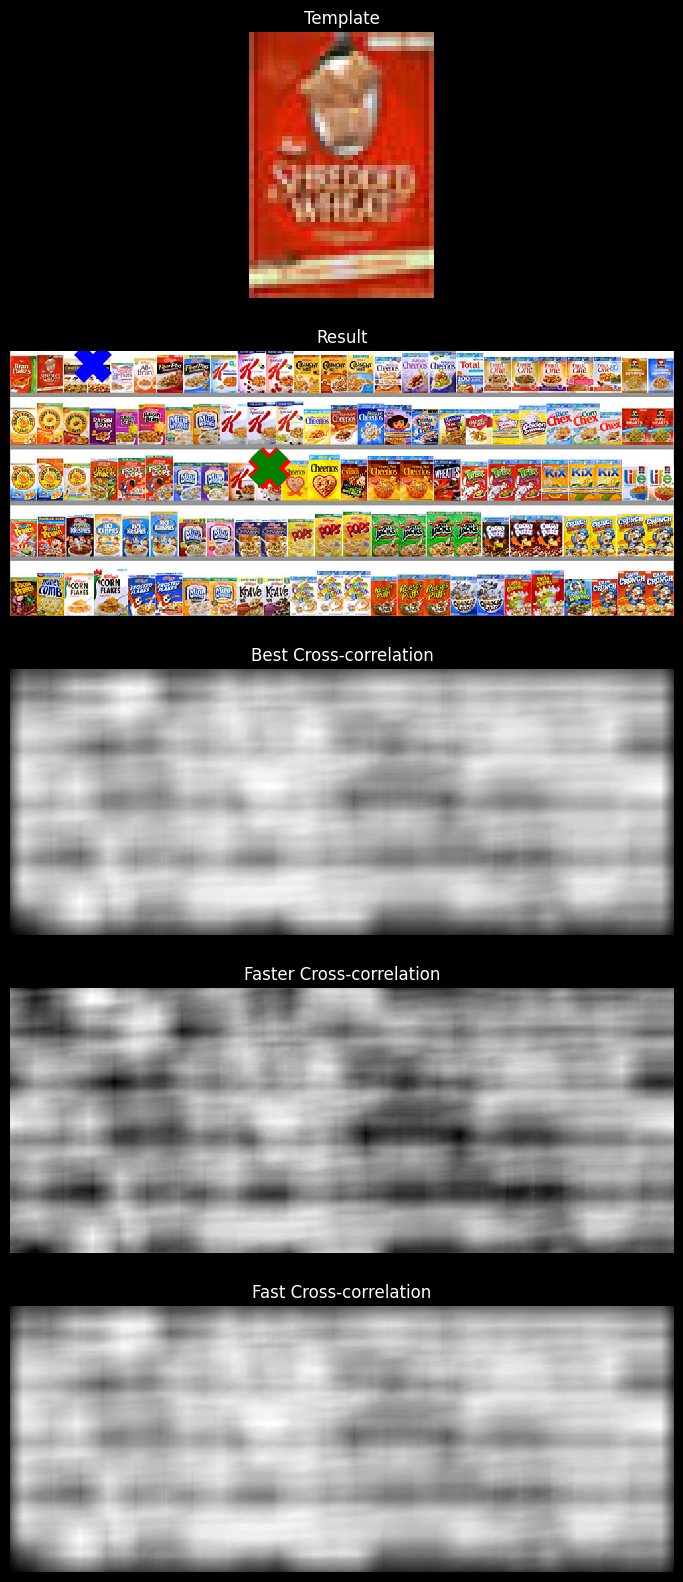

In [30]:
out_best = CrossCorrelation(img_grey, temp_grey, ConvLevel.Best)
out_faster = CrossCorrelation(img_grey, temp_grey, ConvLevel.Faster)
out_fast = CrossCorrelation(img_grey, temp_grey, ConvLevel.Fast)

y_best, x_best = np.unravel_index(out_best.argmax(), out_best.shape)
y_faster, x_faster = np.unravel_index(out_faster.argmax(), out_faster.shape)
y_fast, x_fast = np.unravel_index(out_fast.argmax(), out_fast.shape)

plt.figure(figsize=(25, 20))

plt.subplot(5, 1, 1)
plt.imshow(temp)
plt.title('Template')
plt.axis('off') 

plt.subplot(5, 1, 2)
plt.imshow(img)
plt.title('Result')
plt.axis('off')

plt.plot(x_best, y_best, 'rx', ms=20, mew=15)
plt.plot(x_faster, y_faster, 'bx', ms=20, mew=10)
plt.plot(x_fast, y_fast, 'gx', ms=20, mew=10)

plt.subplot(5, 1, 3)
plt.imshow(out_fast)
plt.title('Best Cross-correlation')
plt.axis('off')

plt.subplot(5, 1, 4)
plt.imshow(out_faster)
plt.title('Faster Cross-correlation')
plt.axis('off')

plt.subplot(5, 1, 5)
plt.imshow(out_fast)
plt.title('Fast Cross-correlation')
plt.axis('off')

plt.show()

### Интерпретация

Как выглядит вывод кросс-корреляционного фильтра? Способен ли он правильно определить продукт? Объясните, какие проблемы могут возникнуть при использовании необработанного шаблона в качестве фильтра.

**Ваш ответ:** * Запишите ваше решение в эту ячейку с пометками.*

---
## Нулевая кросс-корреляция

Решение этой проблемы заключается в вычитании среднего значения шаблона так, чтобы оно имело нулевое среднее значение.

Реализуйте функцию **`zero_mean_cross_correlation`** в файле **`filters.py`** и запустите код ниже.

**Если ваша реализация корректна, то вы должны увидеть синий крест по центру от правильной коробки с хлопьями**.

In [31]:
from filters import ZeroMeanCrossCorrelation

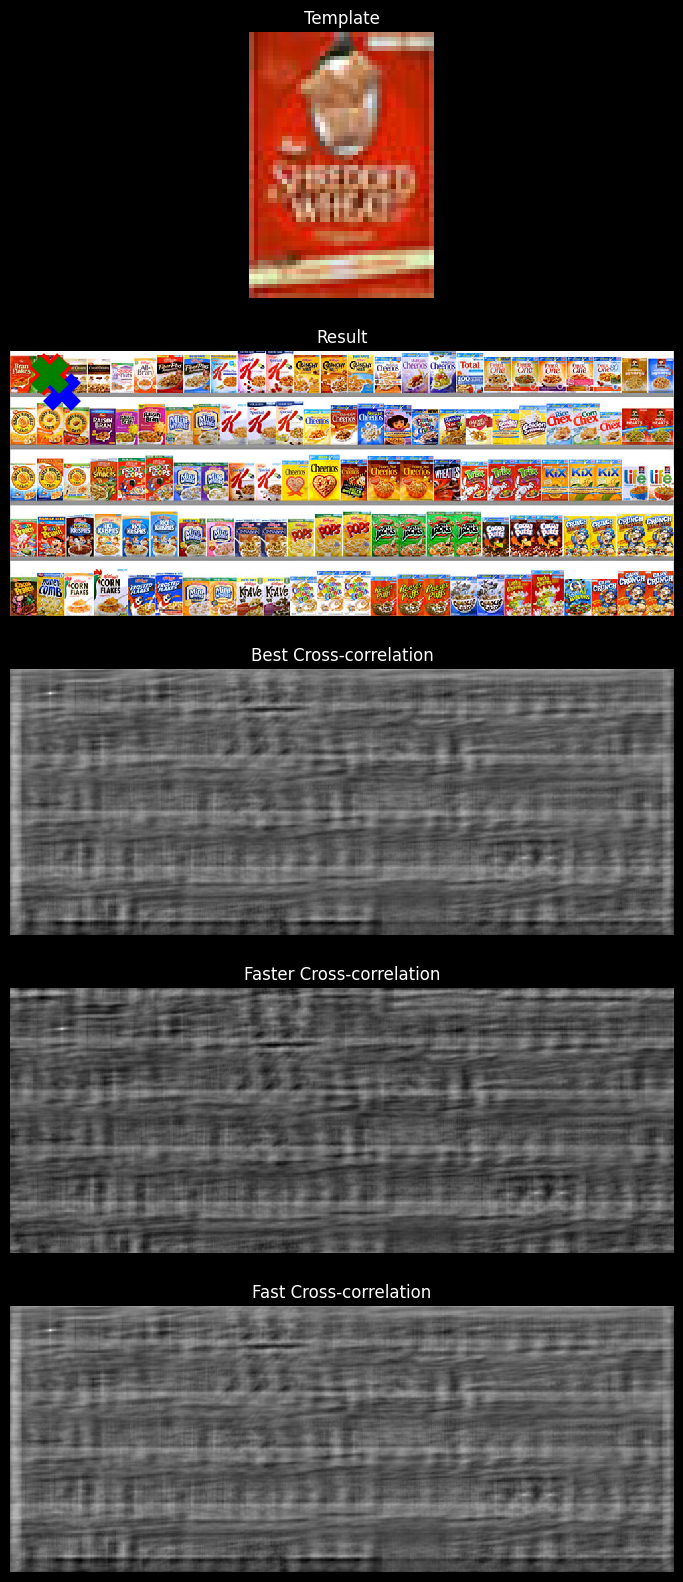

In [32]:
out_best = ZeroMeanCrossCorrelation(img_grey, temp_grey, ConvLevel.Best)
out_faster = ZeroMeanCrossCorrelation(img_grey, temp_grey, ConvLevel.Faster)
out_fast = ZeroMeanCrossCorrelation(img_grey, temp_grey, ConvLevel.Fast)

y_best, x_best = np.unravel_index(out_best.argmax(), out_best.shape)
y_faster, x_faster = np.unravel_index(out_faster.argmax(), out_faster.shape)
y_fast, x_fast = np.unravel_index(out_fast.argmax(), out_fast.shape)

plt.figure(figsize=(25, 20))

plt.subplot(5, 1, 1)
plt.imshow(temp)
plt.title('Template')
plt.axis('off') 

plt.subplot(5, 1, 2)
plt.imshow(img)
plt.title('Result')
plt.axis('off')

plt.plot(x_best, y_best, 'rx', ms=20, mew=15)
plt.plot(x_faster, y_faster, 'bx', ms=20, mew=10)
plt.plot(x_fast, y_fast, 'gx', ms=20, mew=10)

plt.subplot(5, 1, 3)
plt.imshow(out_fast)
plt.title('Best Cross-correlation')
plt.axis('off')

plt.subplot(5, 1, 4)
plt.imshow(out_faster)
plt.title('Faster Cross-correlation')
plt.axis('off')

plt.subplot(5, 1, 5)
plt.imshow(out_fast)
plt.title('Fast Cross-correlation')
plt.axis('off')

plt.show()

Кроме того, можно определить наличие продукта с соответствующим масштабированием и пороговым значением.

In [33]:
from filters import IsProductOnShelf

In [34]:
# Load image of the shelf without the product
img2 = cv2.imread('img/shelf_soldout.jpg')
img2 = cv2.cvtColor(img2, cv2.COLOR_BGR2RGB)
img2_grey = cv2.imread('img/shelf_soldout.jpg', 0)

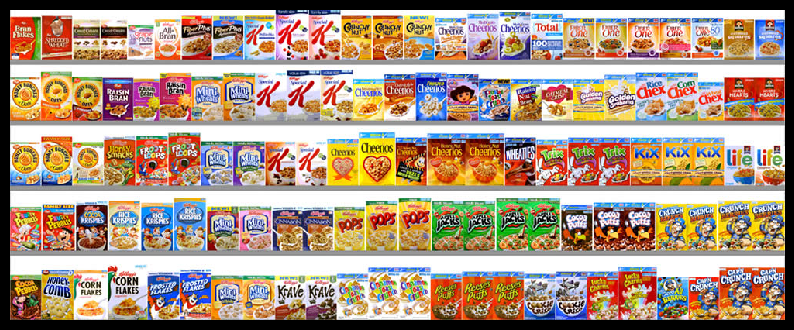

ConvLevel.Best: the product is on the shelf
ConvLevel.Faster: the product is on the shelf
ConvLevel.Fast: the product is on the shelf


In [35]:
plt.figure(figsize=(10, 5))
plt.imshow(img)
plt.axis('off')
plt.show()

IsProductOnShelf(img_grey, temp_grey, ConvLevel.Best)
IsProductOnShelf(img_grey, temp_grey, ConvLevel.Faster)
IsProductOnShelf(img_grey, temp_grey, ConvLevel.Fast)

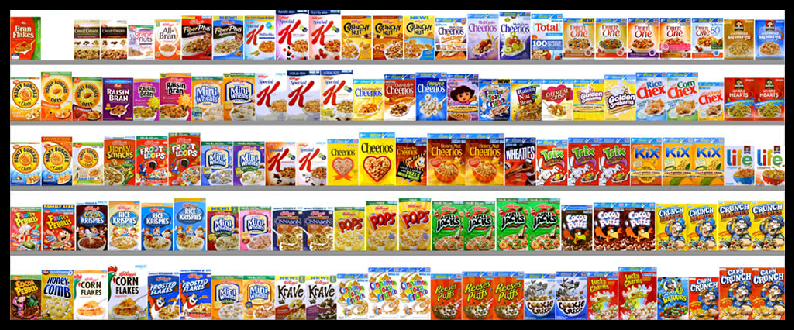

ConvLevel.Best: the product is not on the shelf
ConvLevel.Faster: the product is on the shelf
ConvLevel.Fast: the product is not on the shelf


In [36]:
plt.figure(figsize=(10, 5))
plt.imshow(img2)
plt.axis('off')
plt.show()

IsProductOnShelf(img2_grey, temp_grey, ConvLevel.Best)
IsProductOnShelf(img2_grey, temp_grey, ConvLevel.Faster)
IsProductOnShelf(img2_grey, temp_grey, ConvLevel.Fast)

---
## Нормализованная кросс-корреляция
Однажды свет возле полки погаснет, и устройство слежения за продуктами начнет работать неисправно. `zero_mean_cross_correlation` не устойчива к изменению состояния освещения. Код, приведенный ниже, демонстрирует это.

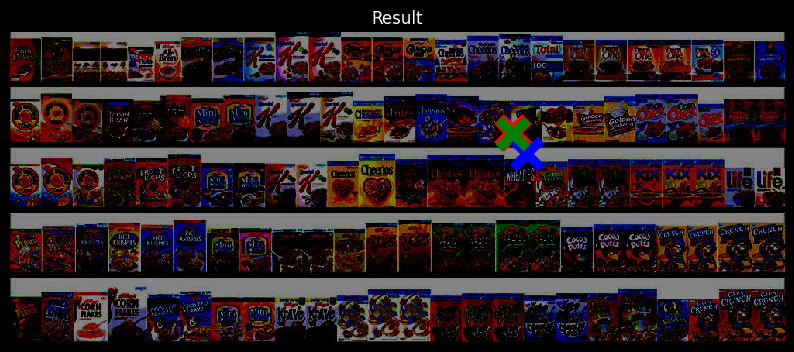

In [37]:
# Load image
img = cv2.imread('img/shelf_dark.jpg')
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img_grey = cv2.imread('img/shelf_dark.jpg', 0)

# Perform cross-correlation between the image and the template
out_best = ZeroMeanCrossCorrelation(img_grey, temp_grey, ConvLevel.Best)
out_faster = ZeroMeanCrossCorrelation(img_grey, temp_grey, ConvLevel.Faster)
out_fast = ZeroMeanCrossCorrelation(img_grey, temp_grey, ConvLevel.Fast)

y_best, x_best = np.unravel_index(out_best.argmax(), out_best.shape)
y_faster, x_faster = np.unravel_index(out_faster.argmax(), out_faster.shape)
y_fast, x_fast = np.unravel_index(out_fast.argmax(), out_fast.shape)

plt.figure(figsize=(10, 5))

# Display image
plt.imshow(img)
plt.title('Result')
plt.axis('off')

plt.plot(x_best, y_best, 'rx', ms=20, mew=10)
plt.plot(x_faster, y_faster, 'bx', ms=20, mew=7)
plt.plot(x_fast, y_fast, 'gx', ms=20, mew=7)
plt.show()

Решение заключается в нормализации пикселей изображения и шаблона на каждом шаге перед их сравнением. Это называется **нормализованной кросс-корреляцией**.

Математическим определением нормализованной кросс-корреляции является $f$ и шаблон $g$:
$$(f\star{g})[m,n]=\sum_{i,j} \frac{f[i,j]-\overline{f_{m,n}}}{\sigma_{f_{m,n}}} \cdot \frac{g[i-m,j-n]-\overline{g}}{\sigma_g}$$

Где:
- $f_{m,n}$ - это патч-изображение в позиции $(m,n)$
- $\overline{f_{m,n}}$ - это среднее значение изображения патча $f_{m,n}$.
- $\sigma_{f_{m,n}}$ - стандартное отклонение изображения патча $f_{m,n}$ 
- $\overline{g}$ - это среднее значение шаблона $g$.
- $\sigma_g$ - стандартное отклонение шаблона $g$.

Реализуйте функцию **`normalized_cross_correlation`** в файле **`filters.py`** и запустите код ниже.

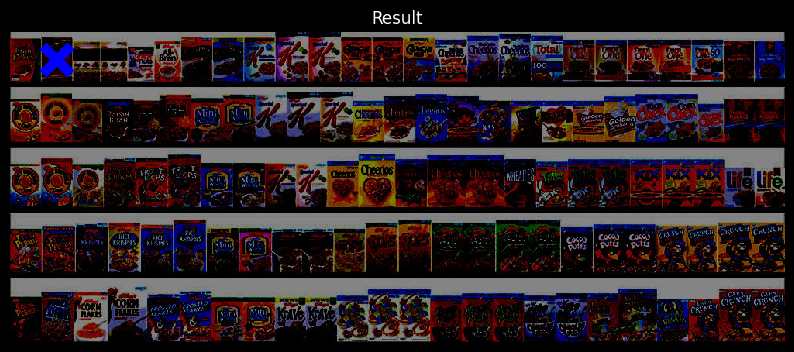

In [38]:
from filters import NormalizedCrossCorrelation

# Perform normalized cross-correlation between the image and the template
out = NormalizedCrossCorrelation(img_grey, temp_grey)

# Find the location with maximum similarity
y, x = np.unravel_index(out.argmax(), out.shape)

plt.figure(figsize=(10, 5))

# Display image
plt.imshow(img)
plt.title('Result')
plt.axis('off')

# Draw marker at detected location
plt.plot(x, y, 'bx', ms=20, mew=7)
plt.show()